In [161]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path1 = '/content/CarPrice_Assignment.csv'
df = pd.read_csv(path1)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [162]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


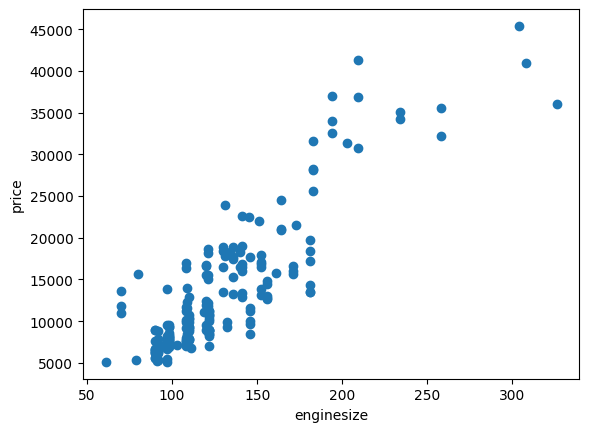

the predicted value of price for engine size 200 is
[25534.23774749]


In [163]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#linear regrewssion
X=df['enginesize'].values.reshape(-1, 1)
y=df['price']
plt.scatter(X,y)
plt.xlabel('enginesize')
plt.ylabel('price')
plt.show()

# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict([[200]])
print("the predicted value of price for engine size 200 is")
print(y_pred)

In [164]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = df['enginesize'].values.reshape(-1, 1)
y = df['price']


In [165]:
lin_model = LinearRegression()
lin_model.fit(X, y)


LinearRegression()

In [166]:
X_sorted = np.sort(X, axis=0)
y_lin_pred = lin_model.predict(X_sorted)


In [167]:
X_sorted = np.sort(X, axis=0)
y_lin_pred = lin_model.predict(X_sorted)


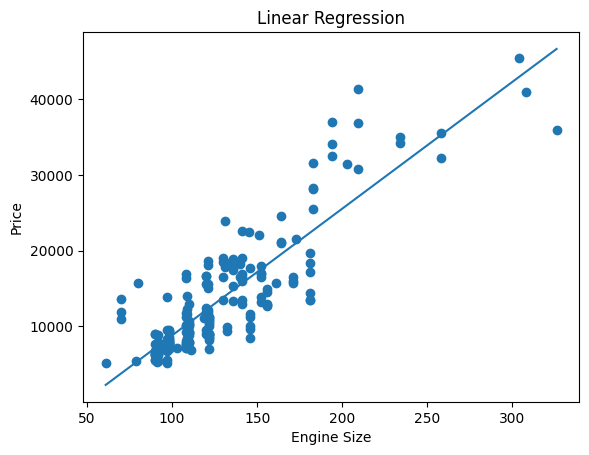

In [168]:
plt.scatter(X, y)
plt.plot(X_sorted, y_lin_pred)
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Linear Regression')
plt.show()


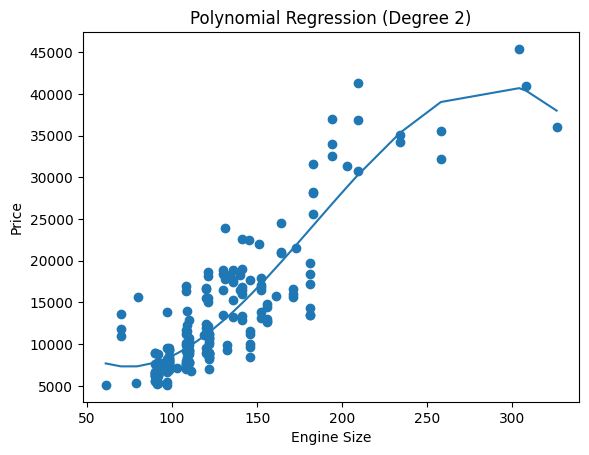

In [169]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
X_poly_sorted = poly.transform(X_sorted)
y_poly_pred = poly_model.predict(X_poly_sorted)
plt.scatter(X, y)
plt.plot(X_sorted, y_poly_pred)
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Polynomial Regression (Degree 2)')
plt.show()

In [170]:
# Linear metrics
lin_mse = mean_squared_error(y, lin_model.predict(X))
lin_r2 = r2_score(y, lin_model.predict(X))

# Polynomial metrics
poly_mse = mean_squared_error(y, poly_model.predict(X_poly))
poly_r2 = r2_score(y, poly_model.predict(X_poly))

print("Linear Regression:")
print("MSE:", lin_mse)
print("R2 Score:", lin_r2)

print("\nPolynomial Regression:")
print("MSE:", poly_mse)
print("R2 Score:", poly_r2)


Linear Regression:
MSE: 14980261.40555132
R2 Score: 0.7641291357806176

Polynomial Regression:
MSE: 13091408.850448111
R2 Score: 0.7938699575522645


In [171]:

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
engine_size = [[200]]

linear_pred = lin_model.predict(engine_size)
poly_pred = poly_model.predict(poly.transform(engine_size))

print("Linear model prediction:", linear_pred)
print("Curved model prediction:", poly_pred)


Linear model prediction: [25534.23774749]
Curved model prediction: [25591.79170895]


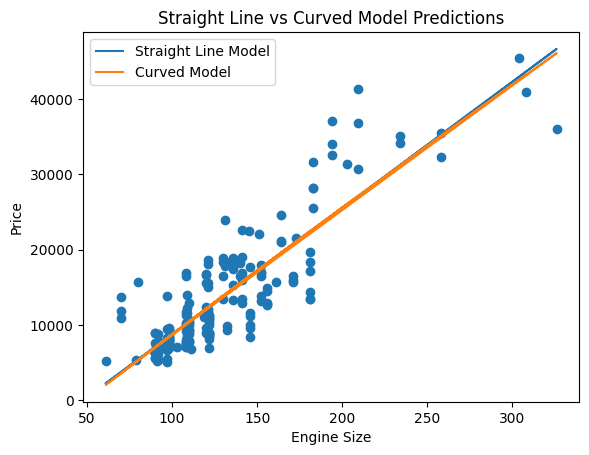

In [172]:
X_sorted =X

# Predictions
y_lin = lin_model.predict(X_sorted)
y_poly = poly_model.predict(poly.transform(X_sorted))

# Plot
plt.scatter(X, y)
plt.plot(X_sorted, y_lin, label='Straight Line Model')
plt.plot(X_sorted, y_poly, label='Curved Model')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Straight Line vs Curved Model Predictions')
plt.legend()
plt.show()


Linear model prediction: [25534.23774749]
Polynomial degree-2 prediction: [25591.79170895]
Polynomial degree-4 prediction: [28205.1318485]


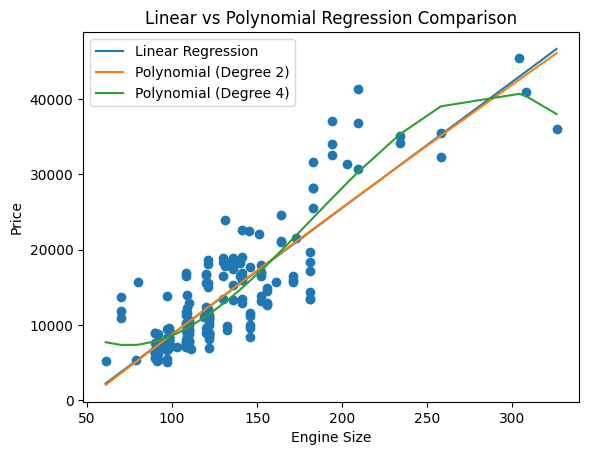

In [173]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt


X = df['enginesize'].values.reshape(-1, 1)
y = df['price']


lin_model = LinearRegression()
lin_model.fit(X, y)

# -----------------------------
# 2. Polynomial Regression (Degree 2)
# -----------------------------
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

poly2_model = LinearRegression()
poly2_model.fit(X_poly2, y)

# -----------------------------
# 3. Polynomial Regression (Degree 4)
# -----------------------------
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)

poly4_model = LinearRegression()
poly4_model.fit(X_poly4, y)

# -----------------------------
# Predictions for engine size = 200
# -----------------------------
engine_size = [[200]]

linear_pred = lin_model.predict(engine_size)
poly2_pred = poly2_model.predict(poly2.transform(engine_size))
poly4_pred = poly4_model.predict(poly4.transform(engine_size))

print("Linear model prediction:", linear_pred)
print("Polynomial degree-2 prediction:", poly2_pred)
print("Polynomial degree-4 prediction:", poly4_pred)

# -----------------------------
# Visualization
# -----------------------------
X_sorted = np.sort(X, axis=0)

y_lin = lin_model.predict(X_sorted)
y_poly2 = poly2_model.predict(poly2.transform(X_sorted))
y_poly4 = poly4_model.predict(poly4.transform(X_sorted))

plt.scatter(X, y)
plt.plot(X_sorted, y_lin, label='Linear Regression')
plt.plot(X_sorted, y_poly2, label='Polynomial (Degree 2)')
plt.plot(X_sorted, y_poly4, label='Polynomial (Degree 4)')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Linear vs Polynomial Regression Comparison')
plt.legend()
plt.show()


In [174]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
y_lin_pred = lin_model.predict(X)
y_poly2_pred = poly2_model.predict(X_poly2)
y_poly4_pred = poly4_model.predict(X_poly4)
print("📊 MODEL PERFORMANCE COMPARISON\n")
print("Linear Regression")
print("MSE :", mean_squared_error(y, y_lin_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_lin_pred)))
print("MAE :", mean_absolute_error(y, y_lin_pred))
print("R2  :", r2_score(y, y_lin_pred))
print("-" * 40)
print("Polynomial Regression (Degree 2)")
print("MSE :", mean_squared_error(y, y_poly2_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_poly2_pred)))
print("MAE :", mean_absolute_error(y, y_poly2_pred))
print("R2  :", r2_score(y, y_poly2_pred))
print("-" * 40)

print("Polynomial Regression (Degree 4)")
print("MSE :", mean_squared_error(y, y_poly4_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_poly4_pred)))
print("MAE :", mean_absolute_error(y, y_poly4_pred))
print("R2  :", r2_score(y, y_poly4_pred))

📊 MODEL PERFORMANCE COMPARISON

Linear Regression
MSE : 14980261.40555132
RMSE: 3870.4342657576967
MAE : 2815.022353836411
R2  : 0.7641291357806176
----------------------------------------
Polynomial Regression (Degree 2)
MSE : 14973637.600078523
RMSE: 3869.578478345997
MAE : 2809.772875118241
R2  : 0.7642334305374976
----------------------------------------
Polynomial Regression (Degree 4)
MSE : 13091408.850448111
RMSE: 3618.2051973938833
MAE : 2692.9296042010114
R2  : 0.7938699575522645


In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsom
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

In [176]:
x=np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y=[0,0,0,0,1,1,1,1,1,1]

In [177]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [178]:
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



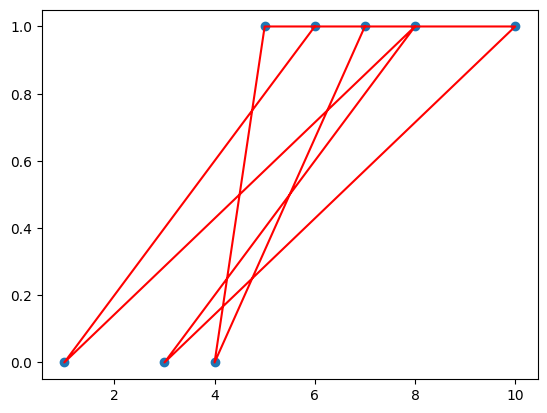

In [179]:
#logistic regression curve
plt.scatter(X_train,y_train)
plt.plot(np.sort(X_train),model.predict(X_train),color='red')
plt.show()

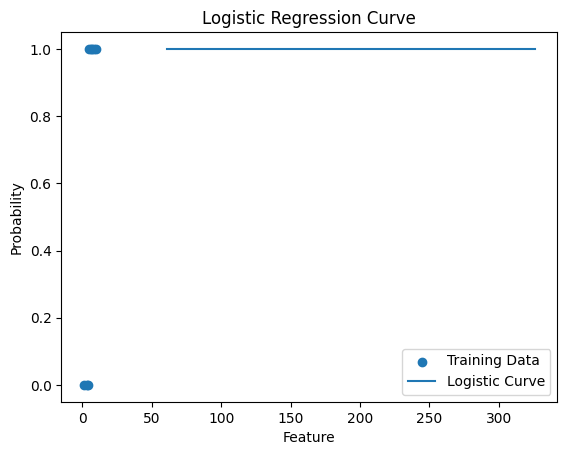

In [180]:
# Create range of X values
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

# Predict probabilities
y_prob = model.predict_proba(X_range)[:, 1]

plt.scatter(X_train, y_train, label='Training Data')
plt.plot(X_range, y_prob, label='Logistic Curve')
plt.xlabel('Feature')
plt.ylabel('Probability')
plt.title('Logistic Regression Curve')
plt.legend()
plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



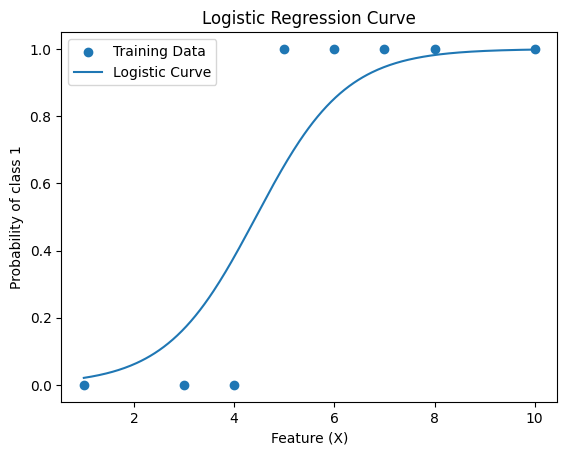

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# -----------------------------
# Data
# -----------------------------
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([0,0,0,0,1,1,1,1,1,1])

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Logistic Regression
# -----------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_prob = model.predict_proba(X_range)[:, 1]
plt.scatter(X_train, y_train, label='Training Data')
plt.plot(X_range, y_prob, label='Logistic Curve')
plt.xlabel('Feature (X)')
plt.ylabel('Probability of class 1')
plt.title('Logistic Regression Curve')
plt.legend()
plt.show()

In [182]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[1 0]
 [0 1]]


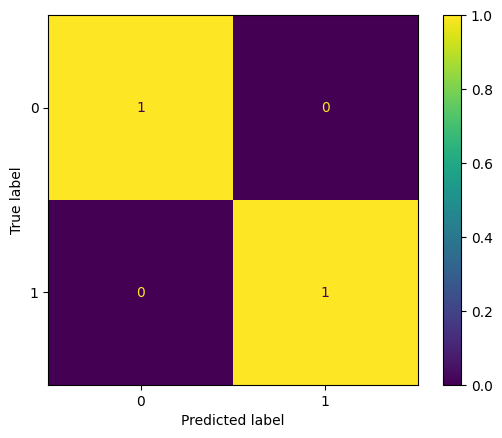

In [183]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [184]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path1 = '/content/heart (2).csv'
df = pd.read_csv(path1)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [185]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [186]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
st=StandardScaler()
x=df.drop('target',axis=1)
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=2,random_state=42)
scalar=StandardScaler()
x_train=scalar.fit_transform(X_train)
x_test=scalar.transform(X_test)
#

<Axes: xlabel='target', ylabel='count'>

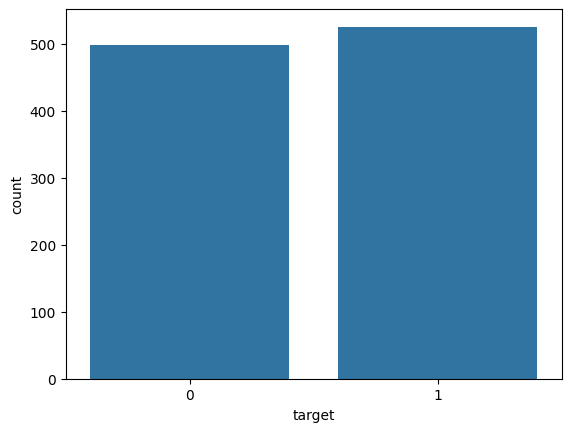

In [187]:
sns.countplot(x=df['target'])
#

In [188]:
model = LogisticRegression()
model.fit(x_train, y_train)




LogisticRegression()

In [189]:
# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(x_test)
print("predictions",predictions)
print(classification_report(y_test, predictions))


predictions [1 1]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Predictions: [1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1
 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0]

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



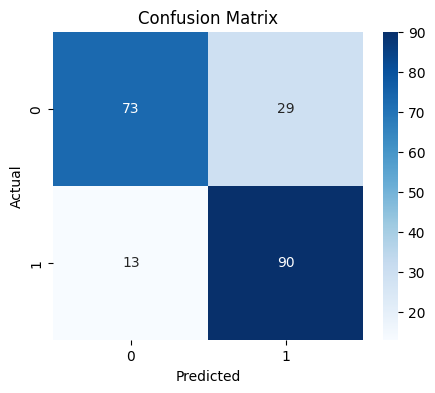

In [190]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from google.colab import drive
drive.mount('/content/drive')

path = '/content/heart (2).csv'
df = pd.read_csv(path)

df.head()
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

print("Predictions:", predictions)
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
y_prob = model.predict_proba(X_test_scaled)[:, 1]




In [191]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[73 29]
 [13 90]]


In [192]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from google.colab import drive
drive.mount('/content/drive')

path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [193]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from google.colab import drive
drive.mount('/content/drive')

path = '/content/heart (2).csv'
df = pd.read_csv(path)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [194]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [195]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# The KeyError indicates that 'Contract' and 'PaymentMethod' columns were not found in 'df'.
# To ensure the correct dataset (Telco Customer Churn) is used, we explicitly load it here.
path_telco_churn = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path_telco_churn)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_data = encoder.fit_transform(df[['Contract', 'PaymentMethod']])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out()
)
df.drop(['Contract', 'PaymentMethod'], axis=1, inplace=True)
df = pd.concat([df, encoded_df], axis=1)

# Handle 'No internet service' for relevant features
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['TechSupport'] = df['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

# Convert TotalCharges to numeric, handling missing values (empty strings) by coercing to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop rows where TotalCharges became NaN (these represent customers with no churn data yet)
df.dropna(subset=['TotalCharges'], inplace=True)

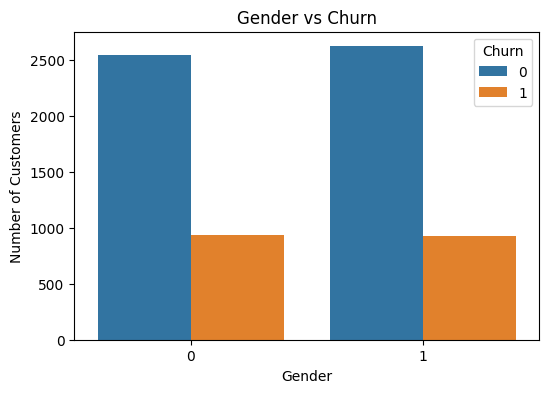

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()
#gender doesnot effect churn

In [197]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,0,...,No,1,29.85,29.85,0,0.0,0.0,0.0,1.0,0.0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,1,...,No,0,56.95,1889.50,0,1.0,0.0,0.0,0.0,1.0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,1,...,No,1,53.85,108.15,1,0.0,0.0,0.0,0.0,1.0
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,1,...,No,0,42.30,1840.75,0,1.0,0.0,0.0,0.0,0.0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,0,...,No,1,70.70,151.65,1,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,1,...,Yes,1,84.80,1990.50,0,1.0,0.0,0.0,0.0,1.0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,0,...,Yes,1,103.20,7362.90,0,1.0,0.0,1.0,0.0,0.0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,1,...,No,1,29.60,346.45,0,0.0,0.0,0.0,1.0,0.0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,0,...,No,1,74.40,306.60,1,0.0,0.0,0.0,0.0,1.0


Accuracy: 0.7889125799573561

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix:
 [[914 119]
 [178 196]]


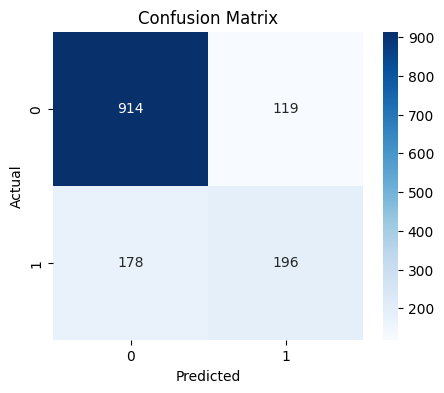

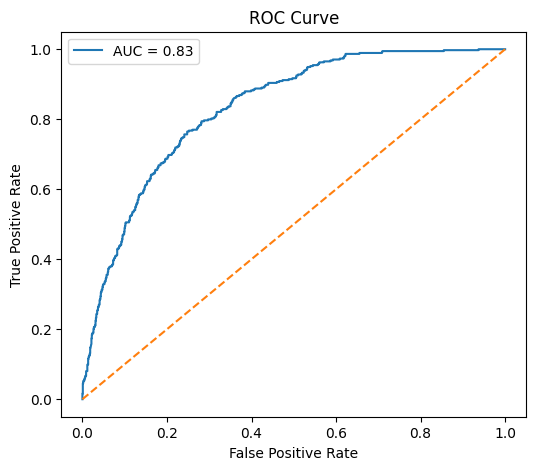


Feature Influence (Logistic Regression Coefficients):
                          Feature  Coefficient
1                  MonthlyCharges     0.794831
5  PaymentMethod_Electronic check     0.209096
4                PaperlessBilling     0.184378
6                     TechSupport    -0.228292
7                  OnlineSecurity    -0.248928
2               Contract_One year    -0.356294
3               Contract_Two year    -0.667427
0                          tenure    -0.775010


In [198]:
# -----------------------------
# IMPORTS
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

# -----------------------------
# SELECT FEATURES & TARGET
# -----------------------------
features = [
    'tenure',
    'MonthlyCharges',
    'Contract_One year',
    'Contract_Two year',
    'PaperlessBilling',
    'PaymentMethod_Electronic check',
    'TechSupport',
    'OnlineSecurity'
]

X = df[features]
y = df['Churn']

# -----------------------------
# TRAIN–TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# FEATURE SCALING
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# LOGISTIC REGRESSION MODEL
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# EVALUATION METRICS
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# CONFUSION MATRIX (PRINT)
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# -----------------------------
# CONFUSION MATRIX (PLOT)
# -----------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# ROC CURVE
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -----------------------------
# FEATURE IMPORTANCE (COEFFICIENTS)
# -----------------------------
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Influence (Logistic Regression Coefficients):")
print(coeff_df)
